Bag of Words

In [1]:
corpus = [
    'Esse é o primeiro documento.',
    'Esse é o segundo.',
    'Seria esse o primeiro?',
]

from sklearn.feature_extraction.text import CountVectorizer

# Create a Vectorizer Object
vectorizer = CountVectorizer()
vectorizer.fit(corpus)

# Printing the identified Unique words along with their indices
print("Vocabulary: ", vectorizer.vocabulary_)

# Encode the Document
vector = vectorizer.transform(corpus)

# Summarizing the Encoded Texts
print("Encoded Document is:")
print(vector.toarray())

Vocabulary:  {'esse': 1, 'primeiro': 2, 'documento': 0, 'segundo': 3, 'seria': 4}
Encoded Document is:
[[1 1 1 0 0]
 [0 1 0 1 0]
 [0 1 1 0 1]]


Detector de Fake News com Bow

In [2]:
#pip install openpyxl
CAMINHO = "C:\\Users\\Nitro\\Desktop\\Redes-Neurais\\Bags_of_Words\\FakeRecogna_no_removal_words.xlsx"


In [3]:
import pandas as pd

dataframe = pd.read_excel(CAMINHO)
dataframe.head()

,Titulo,Subtitulo,Noticia,Categoria,Data,Autor,URL,Classe
0,\n\nArthur Lira fraudou a votação sobre voto i...,Boato – Está comprovado que a votação sobre o ...,bomba lira fraudar o votação brasília explodir...,política,17/08/2021,\nEdgard Matsuki,https://www.boatos.org/politica/arthur-lira-fr...,0
1,WhatsApp agora permite silenciar conversas e g...,"Opção vinha sendo testada no aplicativo, e foi...",o whatsapp liberar quinta-feira atualização ap...,política,23/10/2020 10h02,Por G1,https://g1.globo.com/economia/tecnologia/notic...,1
2,"Com Lula, Bolsonaro e Ciro, Fortaleza vira mic...",NaN,debater propor o cidade o campanha prefeitura ...,política,27/10/2020 04h00,Carlos Madeiro,https://noticias.uol.com.br/eleicoes/2020/10/2...,1
3,Alesp aprova projeto que multa em até R$ 100 m...,NaN,o alesp assembleia legislativo paulo aprovar h...,saúde,10/02/2021 23h56,10/02/2021 23h56,https://noticias.uol.com.br/saude/ultimas-noti...,1
4,\n Não é verdade que Fauci sabia há 15 anos q...,Publicações compartilhadas dezenas de vezes de...,“ fauci aprovar o hidroxicloroquina haver ano ...,saúde,11/08/2020 às 20:45,AFP Austrália,https://checamos.afp.com//nao-e-verdade-que-fa...,0


Word Cloud de Fake News

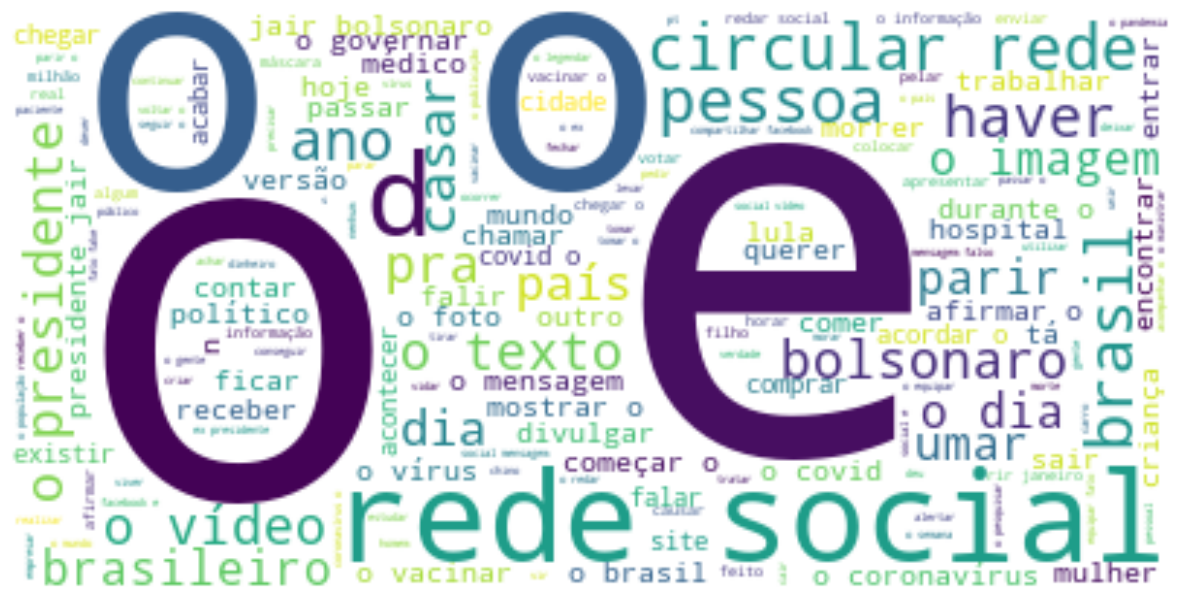

In [4]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
#pip install wordcloud

#notícias falsas
dataframe_fake = dataframe[dataframe["Classe"] == 0]
text = " ".join(i for i in dataframe_fake["Noticia"])
wordcloud = WordCloud(background_color="white").generate(text)

plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


In [5]:
text[:1000]

'bomba lira fraudar o votação brasília explodir votar impresso auditável perder roubar umar haver fraudar o votação o câmara deputar imaginar o eleição presidencial bomba bomba bomba bomba lira fraudar o votação brasília explodir “ fauci aprovar o hidroxicloroquina haver ano curar coronavírus ” o título publicação compartilhar facebook explicar o atual conselheiro o pandemia covid-19 unir anthony fauci supostamente conhecer o eficácia cloroquina e hidroxicloroquina tratamento coronavírus e ocultar o texto justificar “ o virology journal o publicação oficial instituto nacional saudar dr fauci publicar o artigo sucesso agostar o cabeçalho prepare-se “ o cloroquina potente inibidor infecção e disseminação coronavírus sars ” “ significar claro o dr fauci foto haver ano o cloroquina e o hidroxicloroquina derivar suave hcq tratar casar atual coronavírus ‘ terapêutico ’ prevenir caso futuro ‘ profiláticos ’ o hcq funcionar curar e vacinar palavra drogar maravilhoso o coronavírus ” continuar o

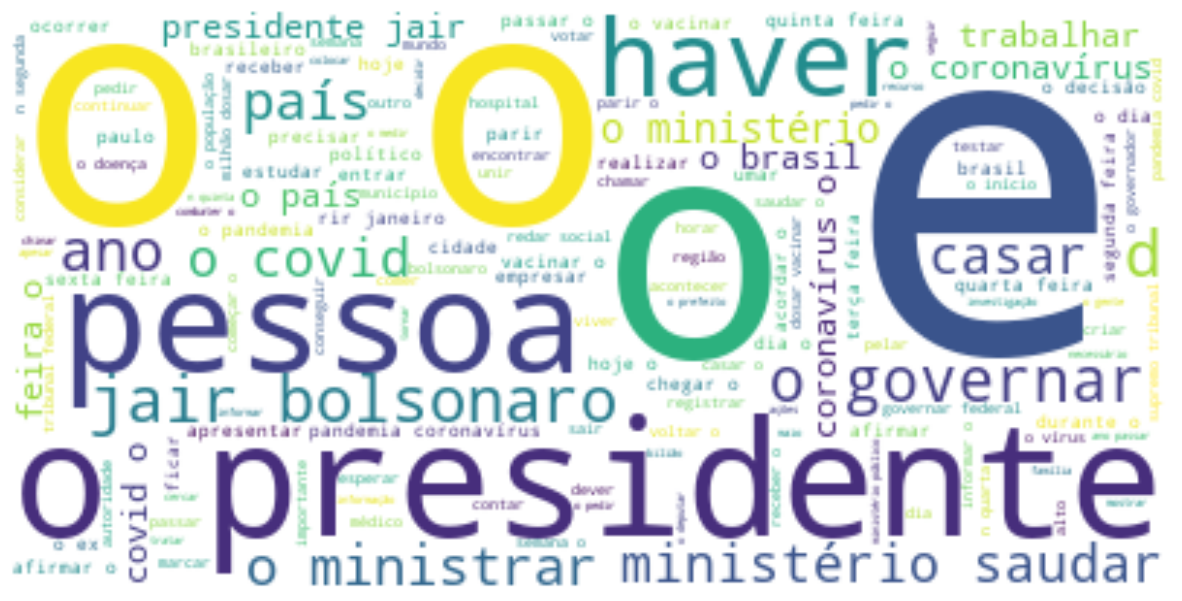

In [6]:
# notícias reais
dataframe_real = dataframe[dataframe["Classe"] == 1]
text = " ".join(i for i in dataframe_real["Noticia"])
wordcloud = WordCloud(background_color="white").generate(text)
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

Classificação

In [7]:
#apenas notícias e rótulos
df_news_labels = dataframe[["Noticia", "Classe"]]

#remover linhas nulas
df_news_labels = df_news_labels.dropna()

#df_news_labels[df_news_labels.isnull().any(axis=1)]

In [8]:
news = df_news_labels.Noticia
labels = df_news_labels.Classe #0 = fake news; 1 = real news

Classe
0    5951
1    5951
Name: count, dtype: int64


<Axes: >

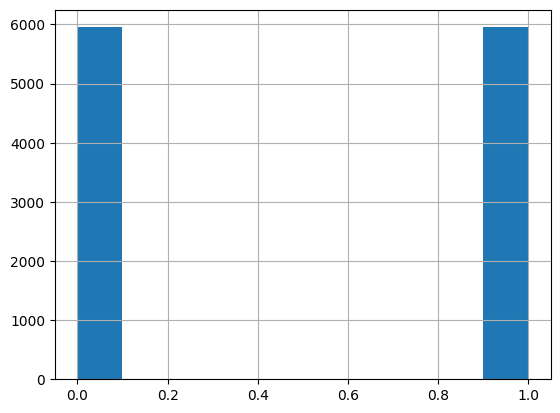

In [9]:
print(labels.value_counts())
labels.hist() #verificar balanceamento

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(news, labels, test_size=0.1)
print(X_test)

2083     casar pessoa infectar coronavírus existir raro...
10273    imaginar livrar passar ano guardar estante fol...
8673     o alemanha lançar estudar pessoa determinar im...
1867     ano e quase brasil o baiano rafaela haver prep...
2652     o imagem começar o circular o comedir quinzena...
                               ...                        
4915     arquirrivais campar corinthians palmeiro santo...
2233     o ministério saudar investir r$ 7,9 milhão pro...
10999    o o sindicância aberto regional medicinar país...
2679     o governar venezuela informar noite hoje dispo...
3107     associação médico americano declarar retirar r...
Name: Noticia, Length: 1191, dtype: str


In [11]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

bow_model = CountVectorizer()
X_train = bow_model.fit_transform(X_train)
X_test = bow_model.transform(X_test)

In [12]:
X_train.shape

(10711, 32540)

In [13]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [14]:
print("Acurácia do treino:", model.score(X_train, y_train))
print("Acurácia do teste:", model.score(X_test, y_test))

Acurácia do treino: 0.9496779012230417
Acurácia do teste: 0.9202350965575147


Após 100 tentativas

In [15]:
from tqdm import tqdm

sum_train = 0
sum_test=0
for i in tqdm(range(200)):
    X_train, X_test, y_train, y_test = train_test_split(news, labels, test_size=0.1)
    bow_model = CountVectorizer()
    X_train = bow_model.fit_transform(X_train)
    X_test = bow_model.transform(X_test)
    model = MultinomialNB()
    model.fit(X_train, y_train)

    sum_train += model.score(X_train, y_train)
    sum_test += model.score(X_test, y_test)

print(sum_train/200, sum_test/200)

100%|██████████| 200/200 [03:18<00:00,  1.01it/s]

0.9498249463168701 0.9197481108312369



Referências
https://repositorio.unesp.br/handle/11449/234317
https://github.com/Gabriel-Lino-Garcia/FakeRecogna
https://thecleverprogrammer.com/2021/11/11/word-cloud-from-a-pandas-dataframe-in-python/
https://www.udemy.com/course/natural-language-processing-in-python/
https://medium.com/co-learning-lounge/nlp-word-embedding-tfidf-bert-word2vec-d7f04340af7f
https://www.geeksforgeeks.org/using-countvectorizer-to-extracting-features-from-text/
https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html
https://machinelearningmastery.com/gentle-introduction-bag-words-model/